In [1]:
import cmocean
import numpy as np 
import xarray as xr
import pandas as pd 
import seaborn as sns
import cartopy.crs as ccrs
import statsmodels.api as sm
import matplotlib.pyplot as plt
from IPython.display import HTML
from scipy.stats import linregress 
from nemo_cookbook import NEMODataTree 
from matplotlib.patches import Rectangle
from OceanDataStore import OceanDataCatalog 
from matplotlib.animation import FuncAnimation

In [2]:
## Heat budget details:
    # Box region: 25-35W, 52-58N
    # Model: 1/4 degree, monthly mean
    # Desnity of seawater: 1025 Kg/m3
    # Speciic heat capacity of seawater: 4000 J/Kg/K
    # Assume constant mixed layer temperature

In [3]:
## Open 5 Day means to compute ddelta H acrosss the month

catalog = OceanDataCatalog(catalog_name="noc-model-stac")
catalog.search(collection='noc-npd-era5')
ds1 = catalog.open_dataset(id=catalog.Items[27].id,
                          start_datetime='1990-01',
                          end_datetime='2024-12')
catalog.search(collection='noc-npd-era5', item_name='domain_cfg')
config = catalog.open_dataset(id=catalog.Items[1].id)

# Merge into a data tree
datasets = {"parent": {"domain": config, "gridT": ds1}}
dt_global = NEMODataTree.from_datasets(datasets = datasets)

# Clip to North Atlantic 
bbox = (-35.0, -25.0, 52.0, 58.0)
dt_clipped = dt_global.clip_grid(grid="gridT", bbox=bbox)

# Add lat and lon as co-ordinates
dt = dt_clipped.add_geoindex(grid="gridT")


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1y
              Title: eORCA1 ERA5v1 NPD T1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/U1y
              Title: eORCA1 ERA5v1 NPD U1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at U-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/V1y
              Title: eORCA1 ERA5v1 NPD V1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global oc

C:\Users\TomAH\anaconda3\envs\env_ods\Lib\site-packages\dask\_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
C:\Users\TomAH\anaconda3\envs\env_ods\Lib\site-packages\dask\_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
C:\Users\TomAH\anaconda3\envs\env_ods\Lib\site-packages\dask\_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
C:\Users\TomAH\anaconda3\envs\env_ods\Lib\site-packages\dask\_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
C:\Users\TomAH\anaconda3\envs\env_ods\Lib\site-packages\dask\_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
C:\Users\TomAH\anaconda3\envs\env_ods\Lib\site-packages\dask\_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
C:\Users\T

In [4]:
dt['gridT']['T_above_MLD'] = dt['gridT']['thetao_con'].sel(k = slice(1, 18))


In [5]:
dt

<xarray.DataTree>
Group: /
│   Dimensions:               (time_counter: 420, axis_nbounds: 2)
│   Coordinates:
│     * time_counter          (time_counter) datetime64[ns] 3kB 1990-01-16T12:00:...
│       time_centered         (time_counter) datetime64[ns] 3kB dask.array<chunksize=(1,), meta=np.ndarray>
│   Dimensions without coordinates: axis_nbounds
│   Data variables:
│       time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 7kB dask.array<chunksize=(1, 2), meta=np.ndarray>
│       time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 7kB dask.array<chunksize=(1, 2), meta=np.ndarray>
│   Attributes:
│       nftype:   None
│       iperio:   False
├── Group: /gridT
│       Dimensions:               (time_counter: 420, k: 75, j: 37, i: 38,
│                                  axis_nbounds: 2)
│       Coordinates:
│         * k                     (k) int64 600B 1 2 3 4 5 6 7 ... 69 70 71 72 73 74 75
│         * j                     (j) int64 296B 926 927 928 929 930 ... 959 960 961 962
│         * i                     (i) int64 304B 1011 1012 1013 1014 ... 1046 1047 1048
│         * deptht                (k) float32 300B 0.5058 1.556 ... 5.698e+03 5.902e+03
│         * gphit                 (j, i) float64 11kB 52.07 52.07 52.08 ... 57.98 57.98
│         * glamt                 (j, i) float64 11kB -34.87 -34.6 ... -25.31 -25.03
│           time_centered         (time_counter) datetime64[ns] 3kB dask.array<chunksize=(1,), meta=np.ndarray>
│       Dimensions without coordinates: axis_nbounds
│       Data variables: (12/31)
│           e3t                   (time_counter, k, j, i) float32 177MB dask.array<chunksize=(1, 25, 37, 38), meta=np.ndarray>
│           ocontempadvect        (time_counter, k, j, i) float32 177MB dask.array<chunksize=(1, 25, 37, 38), meta=np.ndarray>
│           ocontempdiff          (time_counter, k, j, i) float32 177MB dask.array<chunksize=(1, 25, 37, 38), meta=np.ndarray>
│           ocontemppmdiff        (time_counter, k, j, i) float32 177MB dask.array<chunksize=(1, 25, 37, 38), meta=np.ndarray>
│           osaltadvect           (time_counter, k, j, i) float32 177MB dask.array<chunksize=(1, 25, 37, 38), meta=np.ndarray>
│           osaltdiff             (time_counter, k, j, i) float32 177MB dask.array<chunksize=(1, 25, 37, 38), meta=np.ndarray>
│           ...                    ...
│           e2t                   (j, i) float64 11kB dask.array<chunksize=(37, 38), meta=np.ndarray>
│           top_level             (j, i) int32 6kB dask.array<chunksize=(37, 38), meta=np.ndarray>
│           bottom_level          (j, i) int32 6kB dask.array<chunksize=(37, 38), meta=np.ndarray>
│           tmask                 (k, j, i) float64 844kB 1.0 1.0 1.0 ... 0.0 0.0 0.0
│           tmaskutil             (j, i) float64 11kB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0
│           T_above_MLD           (time_counter, k, j, i) float32 177MB dask.array<chunksize=(1, 18, 37, 38), meta=np.ndarray>
│       Indexes:
│         ┌ gphit    NDPointIndex (SklearnGeoBallTreeAdapter)
│         └ glamt
│       Attributes:
│           nftype:   None
│           iperio:   False
├── Group: /gridU
│       Dimensions:       (j: 1206, i: 1440, k: 75)
│       Coordinates:
│         * j             (j) int64 10kB 1 2 3 4 5 6 7 ... 1201 1202 1203 1204 1205 1206
│         * i             (i) float64 12kB 1.5 2.5 3.5 ... 1.438e+03 1.44e+03 1.44e+03
│         * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
│           gphiu         (j, i) float64 14MB dask.array<chunksize=(603, 720), meta=np.ndarray>
│           glamu         (j, i) float64 14MB dask.array<chunksize=(603, 720), meta=np.ndarray>
│       Data variables:
│           e1u           (j, i) float64 14MB dask.array<chunksize=(603, 720), meta=np.ndarray>
│           e2u           (j, i) float64 14MB dask.array<chunksize=(603, 720), meta=np.ndarray>
│           umask         (k, j, i) float64 1GB 0.0 0.0 0.0 0.0 0.0 ... nan nan nan nan
│    

In [6]:

H_ts = (dt.integral(grid='gridT', var='T_above_MLD', dims=['i', 'j', 'k'])) * 1025 * 4000
delta_H = H_ts.resample(time_counter='ME').map(lambda x: x.isel(time_counter=-1) - x.isel(time_counter=0))
days_in_month = H_ts.resample(time_counter='ME').map(lambda x: x.time_counter[-1].dt.day - x.time_counter[0].dt.day)
seconds_in_month = days_in_month * 24 * 60 * 60
dHbydt = (delta_H / seconds_in_month).compute()


In [8]:
dHbydt.to_netcdf('dHbydt_50mintegrated.nc')


In [9]:
# Start from here 

dHbydt = xr.open_dataset('dHbydt_50mintegrated.nc')['__xarray_dataarray_variable__']
Q = xr.open_dataset('Q.nc')['hfds']
integrated_MLD = xr.open_dataset('integrated_MLD.nc')['somxl010']

In [12]:
# Calculate advective term and ratios 

advection = dHbydt - Q
magnitude_ratios = abs(Q) / abs(advection)
heatflux_contribution = Q / dHbydt

In [13]:
dHbydt

<xarray.DataArray '__xarray_dataarray_variable__' (time_counter: 420)> Size: 3kB
array([nan, nan, nan, ..., nan, nan, nan], shape=(420,))
Coordinates:
  * time_counter   (time_counter) datetime64[ns] 3kB 1990-01-31 ... 2024-12-31
    time_centered  (time_counter) datetime64[ns] 3kB ...
Attributes:
    units:               degC
    online_operation:    average
    interval_operation:  1 month
    interval_write:      1 month
    cell_methods:        time: mean
    axis:                T
    time_origin:         1900-01-01 00:00:00
    bounds:              time_counter_bounds

(np.float64(9496.0), np.float64(11292.0))

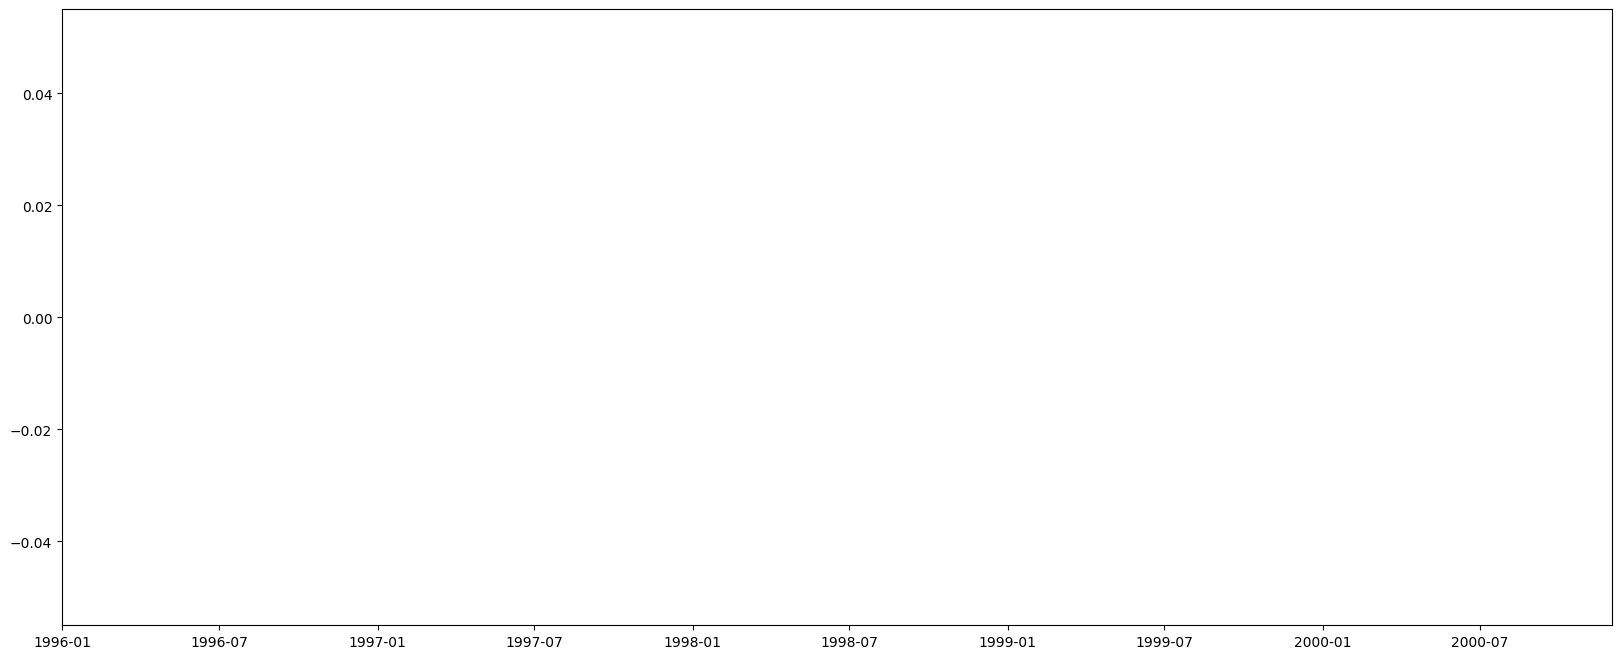

In [11]:
# Change in Heat Content 

fig, ax = plt.subplots(figsize = (20, 8))
ax.plot(dHbydt['time_counter'], dHbydt)
ax.set_xlim(np.datetime64('1996-01-01'), np.datetime64('2000-12-01'))

KeyboardInterrupt: 

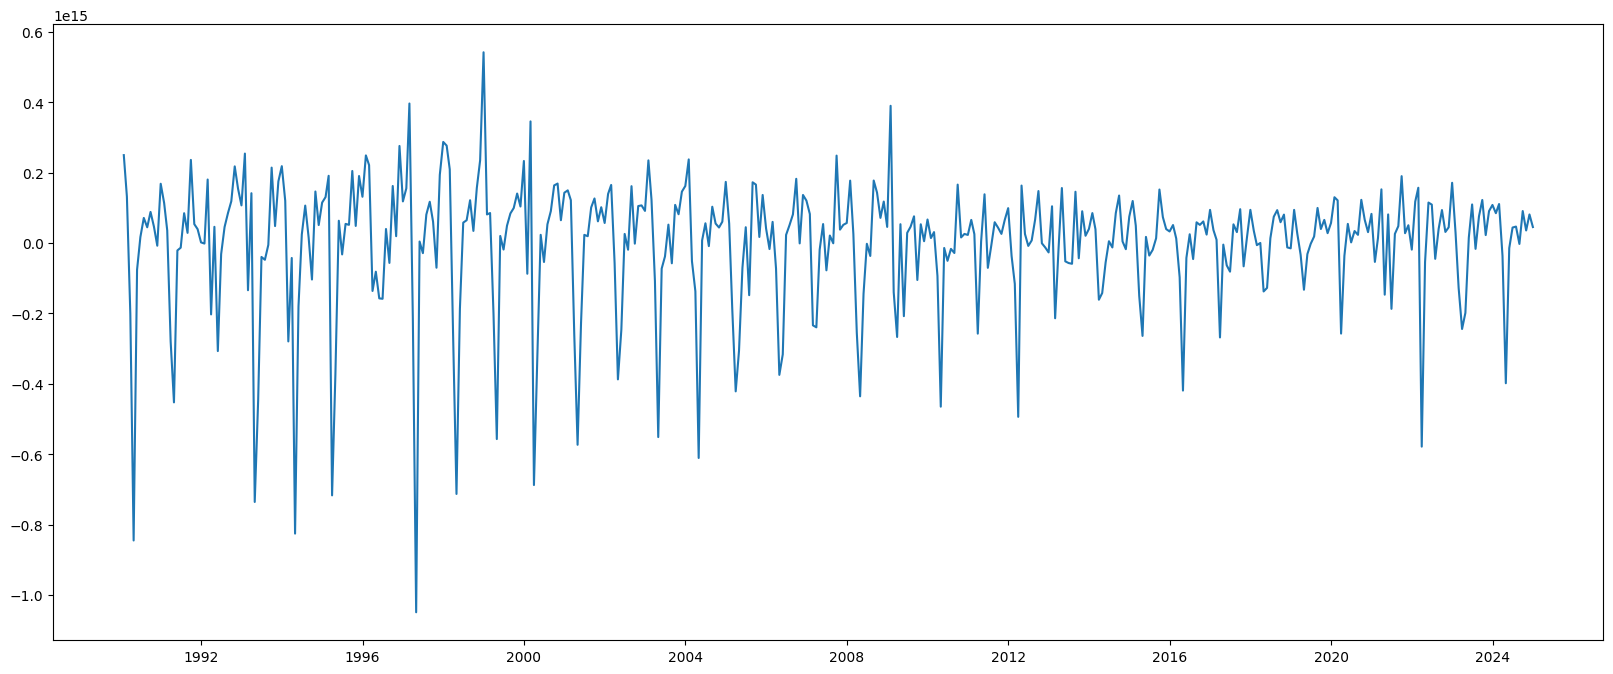

In [9]:
# H and dH/dt 

fig, ax = plt.subplots(figsize = (20, 8))
ax.plot(dHbydt['time_counter'], dHbydt, label = 'dH/dt')
ax.plot(H_ts['time_counter'], H_ts, label = 'H')
ax.legend(loc = 'best')
ax.set_xlim(np.datetime64('1996-01-01'), np.datetime64('2000-12-01'))


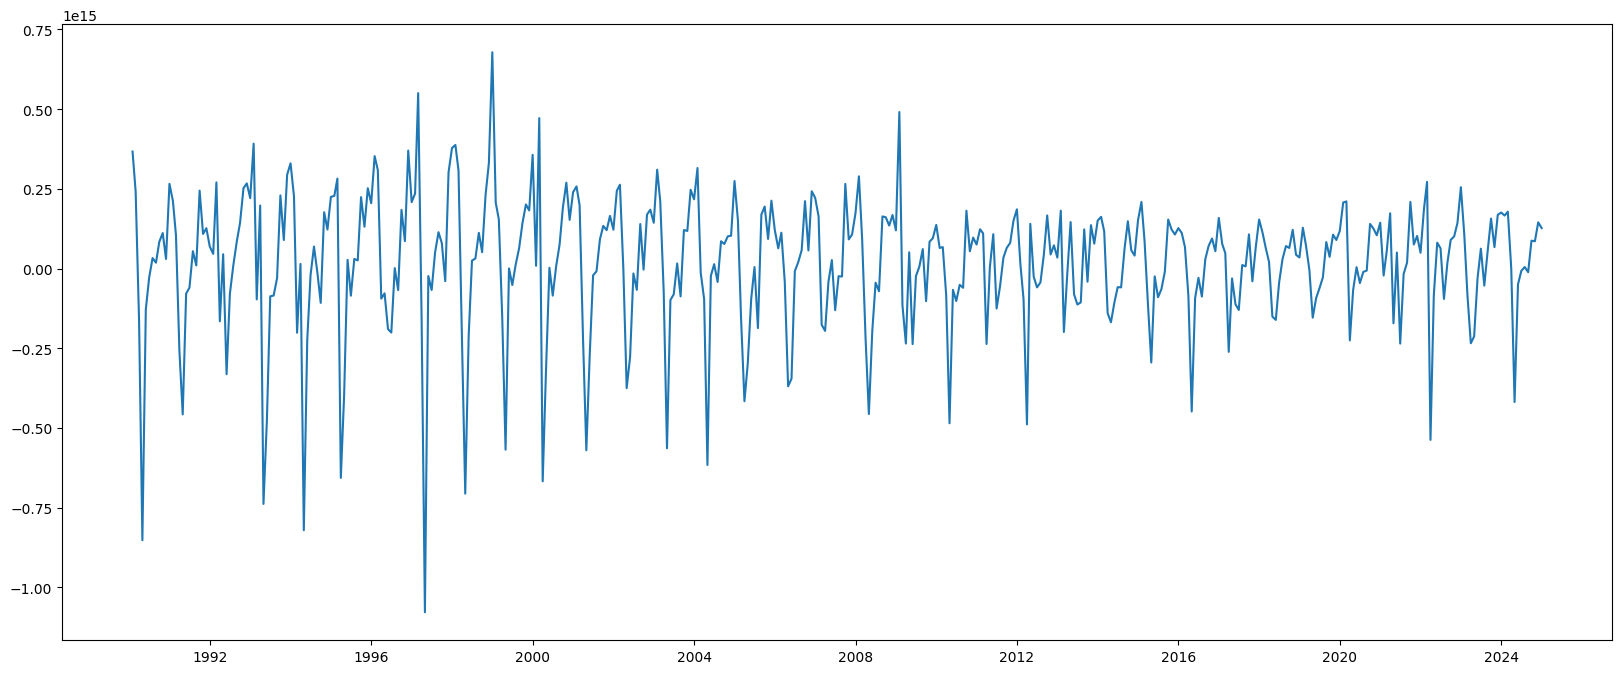

In [23]:
# Plot of advective terms 

fig, ax = plt.subplots(figsize = (20, 8))
ax.plot(advection['time_counter'], advection)
# ax.set_xlim(np.datetime64('1996-01-01'), np.datetime64('2000-12-01'))

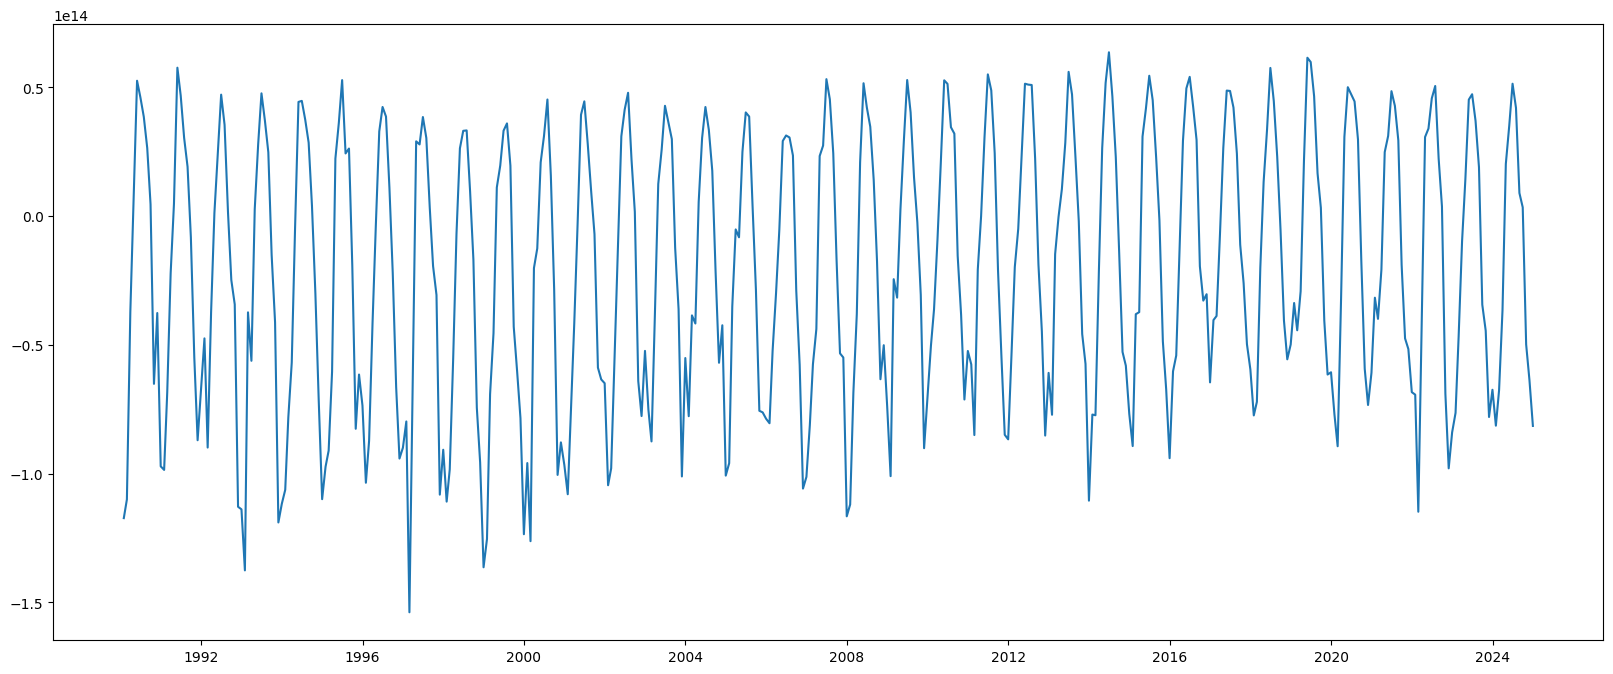

In [21]:
# Surface heat flux terms

fig, ax = plt.subplots(figsize = (20, 8))
ax.plot(Q['time_counter'], Q)
#ax.set_xlim(np.datetime64('1996-01-01'), np.datetime64('2000-12-01'))

In [35]:
integrated_MLD

<xarray.DataArray 'somxl010' (time_counter: 420)> Size: 3kB
array([6.721926e+13, 9.073555e+13, 1.007542e+14, ..., 1.921403e+13,
       2.300892e+13, 3.090036e+13], shape=(420,))
Coordinates:
  * time_counter   (time_counter) datetime64[ns] 3kB 1990-01-16T12:00:00 ... ...
    time_centered  (time_counter) datetime64[ns] 3kB ...
Attributes:
    standard_name:       ocean_mixed_layer_thickness_defined_by_sigma_theta
    long_name:           Mixed Layer Depth (dsigma = 0.01 wrt 10m)
    units:               m
    online_operation:    average
    interval_operation:  1800 s
    interval_write:      1 month
    cell_methods:        time: mean (interval: 1800 s)

Text(0, 0.5, 'Integrated MLD (m3)')

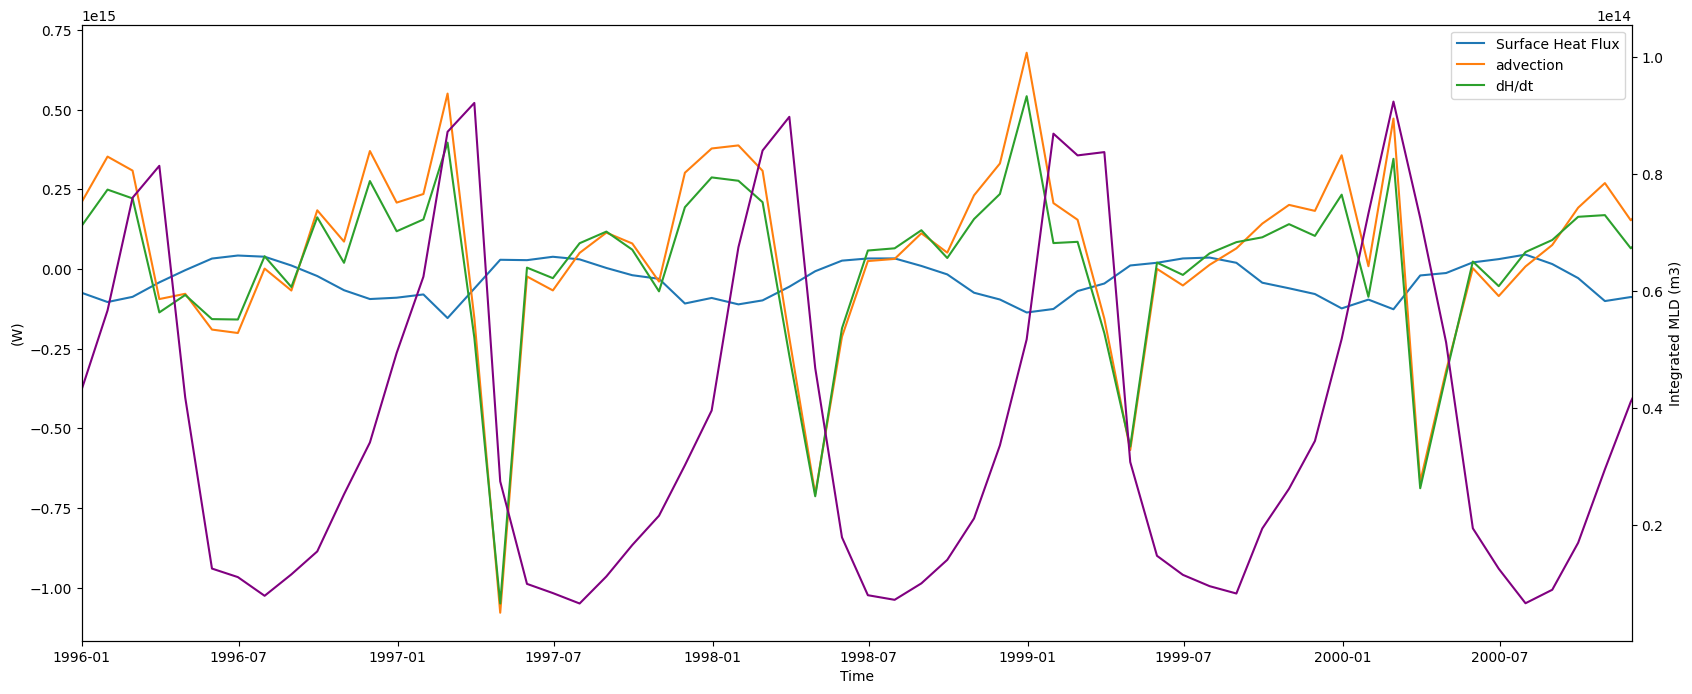

In [46]:
# Surface heat flux vs Advwection vs dH/dt 

fig, ax = plt.subplots(figsize = (20, 8))
ax2 = ax.twinx() 

ax.plot(Q['time_counter'], Q, label = 'Surface Heat Flux')
ax.plot(advection['time_counter'], advection, label = 'advection')
ax.plot(dHbydt['time_counter'], dHbydt, label = 'dH/dt')
ax2.plot(integrated_MLD['time_counter'], integrated_MLD, label = 'Integrated MLD', color = 'purple')
ax.legend(loc = 'best')
ax.set_xlim(np.datetime64('1996-01-01'), np.datetime64('2000-12-01'))
ax.set_xlabel('Time')
ax.set_ylabel('(W)')
ax2.set_ylabel('Integrated MLD (m3)')

(0.0, 5.0)

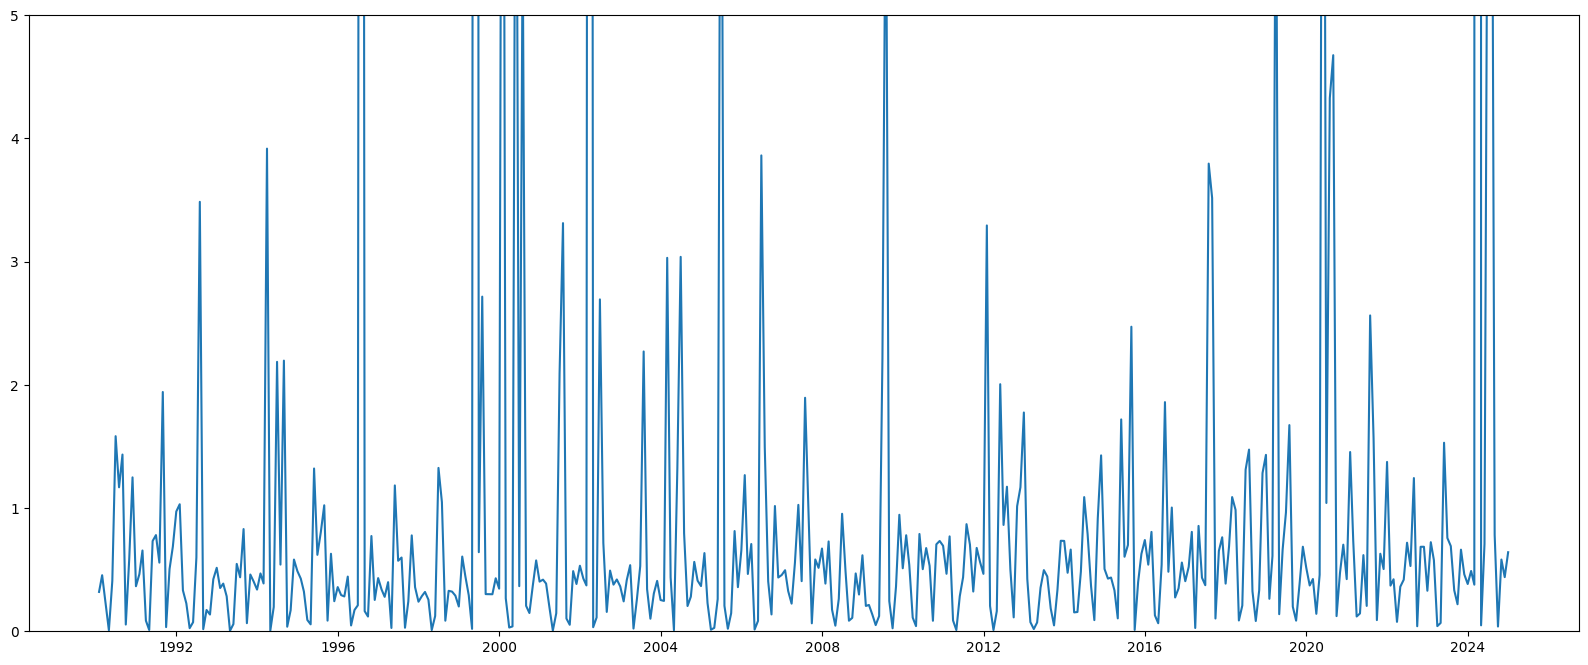

In [50]:
# Magnitude Ratios 

fig, ax = plt.subplots(figsize = (20, 8))
ax.plot(magnitude_ratios['time_counter'], magnitude_ratios)
# ax.set_xlim(np.datetime64('1996-01-01'), np.datetime64('2000-12-01'))
ax.set_ylim(0, 5)


In [51]:
## Now consider Annual Means 

Q_annual = Q.resample(time_counter = 'YE').mean()
advection_annual = advection.resample(time_counter = 'YE').mean()
dHbydt_annual = dHbydt.resample(time_counter = 'YE').mean()

Text(0, 0.5, '(W)')

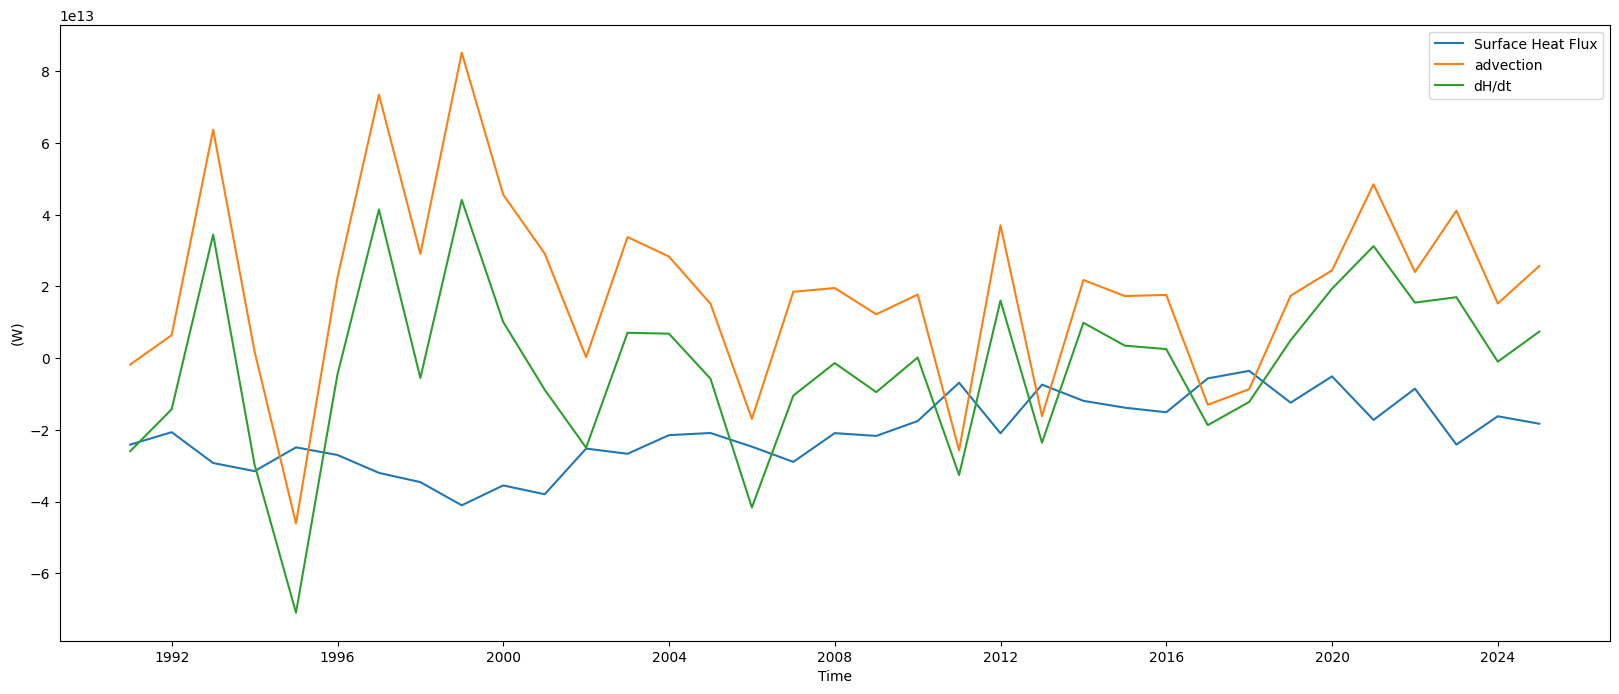

In [52]:
# Surface heat flux vs Advwection vs dH/dt 

fig, ax = plt.subplots(figsize = (20, 8))

ax.plot(Q_annual['time_counter'], Q_annual, label = 'Surface Heat Flux')
ax.plot(advection_annual['time_counter'], advection_annual, label = 'advection')
ax.plot(dHbydt_annual['time_counter'], dHbydt_annual, label = 'dH/dt')
ax.legend(loc = 'best')
# ax.set_xlim(np.datetime64('1996-01-01'), np.datetime64('2000-12-01'))
ax.set_xlabel('Time')
ax.set_ylabel('(W)')

(0.0, 5.0)

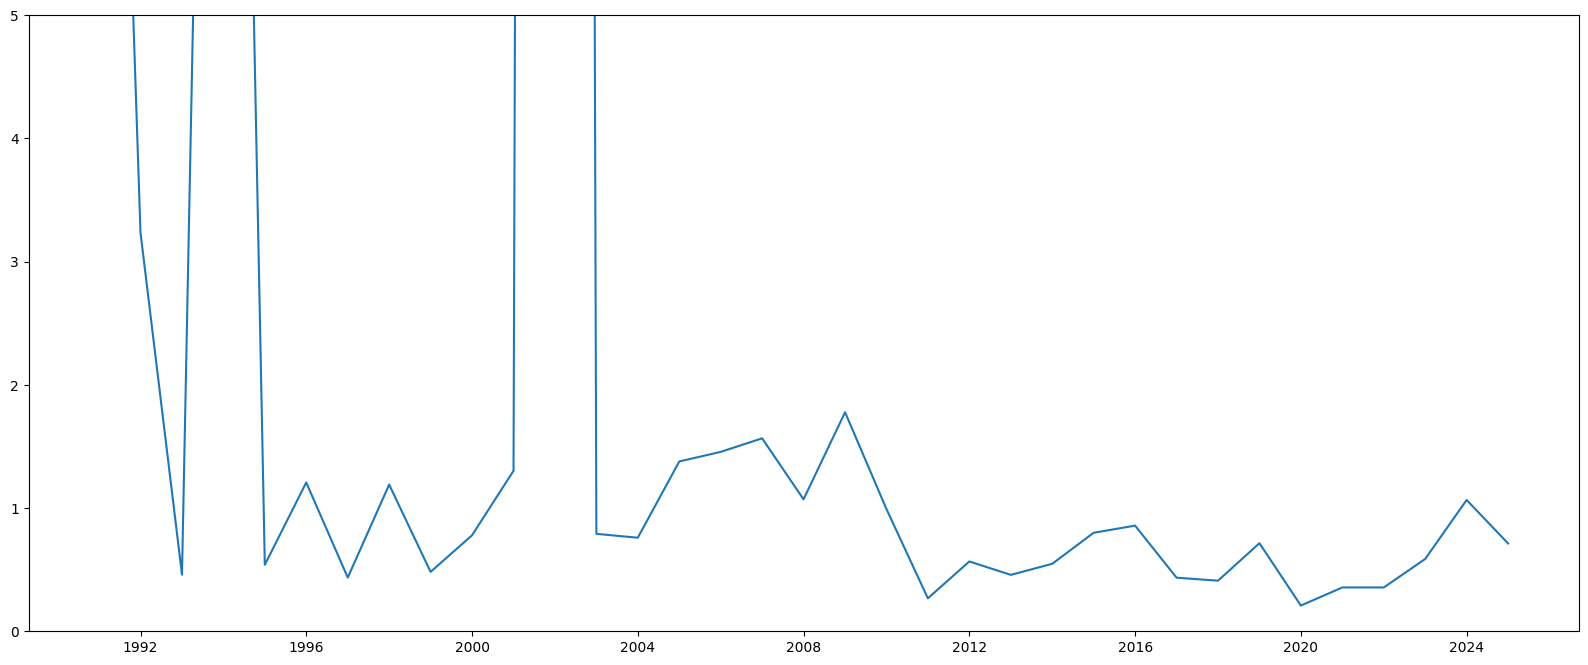

In [57]:
magnitude_ratios_annual = abs(Q_annual) / abs(advection_annual)

# Magnitude Ratios 

fig, ax = plt.subplots(figsize = (20, 8))
ax.plot(magnitude_ratios_annual['time_counter'], magnitude_ratios_annual)
# ax.set_xlim(np.datetime64('1996-01-01'), np.datetime64('2000-12-01'))
ax.set_ylim(0, 5)
